In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [ ]:
project_path = r"G:\XJN_M2project"
model = "test2"
condition = "pre"
group = "depressed"
condition_dir = os.path.join(project_path, "signal_data", model, condition, "group", group)
# If this list is empty, automatically scan the condition directory.
mice_ids = [
f for f in os.listdir(condition_dir) if os.path.isdir(os.path.join(condition_dir, f))
]
print(f"Found {len(mice_ids)} mice in {condition_dir}: {mice_ids}")
auto_discover_mice = False
require_both_modalities = True

# Resampling settings.
target_neuron_count = 15
minimum_neuron_threshold = 10
neuron_sampling_random_seed = 42
resample_seed_iterations = 200

# Logistic-regression settings.
apply_minmax_scaler = True
logreg_test_size = 0.5
logreg_random_state = 42
logreg_max_iter = 1000

# Randomization / simulation settings.
label_shuffle_iterations = 200
synthetic_neuron_iterations = 200
randomization_random_seed = 42

# Plot settings.
hist_bins = 15
figure_size = (8, 5)
alpha_tst = 0.65
alpha_oft = 0.65
save_preview_plots = True

save_root = os.path.join(project_path, "signal_data", model, condition, "group", group)
os.makedirs(save_root, exist_ok=True)
resampled_save_root = os.path.join(save_root, f"resampled_{target_neuron_count}_neurons")
os.makedirs(resampled_save_root, exist_ok=True)


## Analysis Design

This notebook follows the paper-style definition that **each aligned timepoint is one sample**.

- Rows in each aligned table are timepoints.
- Columns are neurons.
- For one mouse, the classifier uses neuron activity at each aligned timepoint to classify `TST` versus `OFT`.

Nerification:

- **Label shuffle**: test whether observed decoding is stronger than chance label assignment.
- **Resample-seed stability**: repeatedly re-sample 15 neurons from the same mouse using different random seeds and measure how stable the decoding accuracy is.
- **Synthetic-neuron simulation**: generate synthetic neurons from each neuron's `mean/std`, rebuild 15-neuron tables, and test whether simple first/second-order statistics alone can support decoding.


In [7]:
def discover_mice_ids(project_path, model, condition):
    condition_dir = Path(project_path) / "signal_data" / model / condition
    if not condition_dir.exists():
        raise FileNotFoundError(f"Condition directory not found: {condition_dir}")

    discovered = []
    for mouse_dir in sorted(condition_dir.iterdir()):
        if not mouse_dir.is_dir():
            continue
        signal_dir = mouse_dir / "signal_save"
        if not signal_dir.exists():
            continue

        tst_path = signal_dir / f"{mouse_dir.name}_{condition}_aligned_table_TST.csv"
        oft_path = signal_dir / f"{mouse_dir.name}_{condition}_aligned_table_OFT.csv"
        if tst_path.exists() or oft_path.exists():
            discovered.append(mouse_dir.name)

    return discovered


def read_aligned_table(csv_path):
    df = pd.read_csv(csv_path)
    unnamed_cols = [col for col in df.columns if str(col).startswith("Unnamed")]
    if unnamed_cols:
        print(f"[Fallback] Dropping index-like columns from {csv_path.name}: {unnamed_cols}")
        df = df.drop(columns=unnamed_cols)
    return df


def summarize_mouse_record(mouse_id, project_path, model, condition, require_both_modalities=True):
    signal_dir = Path(project_path) / "signal_data" / model / condition / mouse_id / "signal_save"
    tst_path = signal_dir / f"{mouse_id}_{condition}_aligned_table_TST.csv"
    oft_path = signal_dir / f"{mouse_id}_{condition}_aligned_table_OFT.csv"

    record = {
        "mouse_id": mouse_id,
        "tst_exists": tst_path.exists(),
        "oft_exists": oft_path.exists(),
        "tst_path": str(tst_path),
        "oft_path": str(oft_path),
        "tst_timepoints": np.nan,
        "oft_timepoints": np.nan,
        "tst_neurons": np.nan,
        "oft_neurons": np.nan,
        "qc_status": "ok",
        "exclude_reason": "",
    }

    if require_both_modalities and (not tst_path.exists() or not oft_path.exists()):
        missing = []
        if not tst_path.exists():
            missing.append("TST")
        if not oft_path.exists():
            missing.append("OFT")
        record["qc_status"] = "excluded"
        record["exclude_reason"] = f"missing modality: {'+'.join(missing)}"
        print(f"[QC] Excluding {mouse_id}: {record['exclude_reason']}")
        return record

    if tst_path.exists():
        tst_df = read_aligned_table(tst_path)
        record["tst_timepoints"] = tst_df.shape[0]
        record["tst_neurons"] = tst_df.shape[1]

    if oft_path.exists():
        oft_df = read_aligned_table(oft_path)
        record["oft_timepoints"] = oft_df.shape[0]
        record["oft_neurons"] = oft_df.shape[1]

    if pd.isna(record["tst_neurons"]) and pd.isna(record["oft_neurons"]):
        record["qc_status"] = "excluded"
        record["exclude_reason"] = "no readable aligned table"
        print(f"[QC] Excluding {mouse_id}: {record['exclude_reason']}")

    return record


def build_neuron_count_long_table(inventory_df):
    long_df = inventory_df.melt(
        id_vars=["mouse_id", "qc_status", "exclude_reason"],
        value_vars=["tst_neurons", "oft_neurons"],
        var_name="task",
        value_name="neuron_count",
    )
    long_df["task"] = long_df["task"].map({"tst_neurons": "TST", "oft_neurons": "OFT"})
    long_df = long_df.dropna(subset=["neuron_count"]).copy()
    long_df["neuron_count"] = long_df["neuron_count"].astype(int)
    return long_df


def sample_neuron_columns(df, target_count, min_count, rng, task_name, mouse_id):
    original_count = df.shape[1]
    if original_count < min_count:
        raise ValueError(
            f"{mouse_id} {task_name} has only {original_count} neurons, below the threshold of {min_count}."
        )

    replace = original_count < target_count
    if replace:
        print(
            f"[Fallback] {mouse_id} {task_name}: {original_count} neurons available; "
            f"sampling with replacement to reach {target_count}."
        )
        selected_idx = rng.choice(original_count, size=target_count, replace=True)
        sampled_df = df.iloc[:, selected_idx].copy()
        sampled_df.columns = [f"{task_name}_sampled_{i:02d}" for i in range(target_count)]
        sampling_mode = "with_replacement"
    else:
        selected_idx = rng.choice(original_count, size=target_count, replace=False)
        sampled_df = df.iloc[:, selected_idx].copy()
        sampled_df.columns = list(df.columns[selected_idx])
        sampling_mode = "without_replacement"

    return sampled_df, selected_idx.tolist(), sampling_mode, original_count


def prepare_timepoint_classification_arrays(tst_path, oft_path, apply_scaler=True):
    tst_df = pd.read_csv(tst_path)
    oft_df = pd.read_csv(oft_path)
    return prepare_timepoint_classification_arrays_from_dfs(
        tst_df=tst_df,
        oft_df=oft_df,
        apply_scaler=apply_scaler,
    )


def prepare_timepoint_classification_arrays_from_dfs(tst_df, oft_df, apply_scaler=True):
    shared_timepoints = min(tst_df.shape[0], oft_df.shape[0])
    if tst_df.shape[0] != oft_df.shape[0]:
        print(
            f"[Fallback] Timepoint mismatch between TST and OFT: "
            f"TST={tst_df.shape[0]}, OFT={oft_df.shape[0]}; truncating to {shared_timepoints}."
        )

    tst_df = tst_df.iloc[:shared_timepoints, :].copy()
    oft_df = oft_df.iloc[:shared_timepoints, :].copy()

    if apply_scaler:
        tst_array = MinMaxScaler().fit_transform(tst_df.to_numpy())
        oft_array = MinMaxScaler().fit_transform(oft_df.to_numpy())
    else:
        print("[Fallback] MinMax scaling disabled; using raw values.")
        tst_array = tst_df.to_numpy()
        oft_array = oft_df.to_numpy()

    X = np.vstack([tst_array, oft_array])
    y = np.hstack([np.zeros(shared_timepoints, dtype=int), np.ones(shared_timepoints, dtype=int)])
    return X, y, shared_timepoints, tst_array, oft_array


def compute_logreg_accuracy(X, y, test_size, random_state, max_iter):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )
    clf = LogisticRegression(max_iter=max_iter, random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "feature_count": X.shape[1],
    }


def run_logreg_from_dfs(tst_df, oft_df, apply_scaler, test_size, random_state, max_iter):
    X, y, shared_timepoints, tst_array, oft_array = prepare_timepoint_classification_arrays_from_dfs(
        tst_df=tst_df,
        oft_df=oft_df,
        apply_scaler=apply_scaler,
    )
    result = compute_logreg_accuracy(
        X=X,
        y=y,
        test_size=test_size,
        random_state=random_state,
        max_iter=max_iter,
    )
    return result, X, y, shared_timepoints, tst_array, oft_array


def generate_synthetic_df_from_mean_std(source_df, rng):
    synthetic_cols = []
    for col_name in source_df.columns:
        col_values = source_df[col_name].to_numpy(dtype=float)
        mu = float(np.mean(col_values))
        sigma = float(np.std(col_values, ddof=0))
        if np.isnan(sigma) or sigma < 1e-12:
            synthetic_col = np.full(source_df.shape[0], mu, dtype=float)
        else:
            synthetic_col = rng.normal(loc=mu, scale=sigma, size=source_df.shape[0])
        synthetic_cols.append(synthetic_col)
    synthetic_array = np.column_stack(synthetic_cols) if synthetic_cols else np.empty((source_df.shape[0], 0))
    return pd.DataFrame(synthetic_array, columns=source_df.columns)


def empirical_p_value(observed_value, null_values):
    null_values = np.asarray(null_values, dtype=float)
    return (np.sum(null_values >= observed_value) + 1) / (len(null_values) + 1)


def summarize_null_distribution(observed_accuracy, null_accuracies):
    null_accuracies = np.asarray(null_accuracies, dtype=float)
    return {
        "observed_accuracy": float(observed_accuracy),
        "null_mean_accuracy": float(null_accuracies.mean()),
        "null_median_accuracy": float(np.median(null_accuracies)),
        "null_std_accuracy": float(null_accuracies.std(ddof=1)) if len(null_accuracies) > 1 else 0.0,
        "null_min_accuracy": float(null_accuracies.min()),
        "null_max_accuracy": float(null_accuracies.max()),
        "empirical_p_value": empirical_p_value(observed_accuracy, null_accuracies),
    }


[Progress] Resolving mouse list...
[Progress] Using user-provided mouse list with n=6.
[Progress] Reading aligned tables and collecting QC records...
[Progress] Saved inventory table to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\paired_signal_inventory.csv
[Progress] Valid mice: 6
[Progress] Excluded mice: 0
[Progress] Saved histogram to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\neuron_count_histogram.png


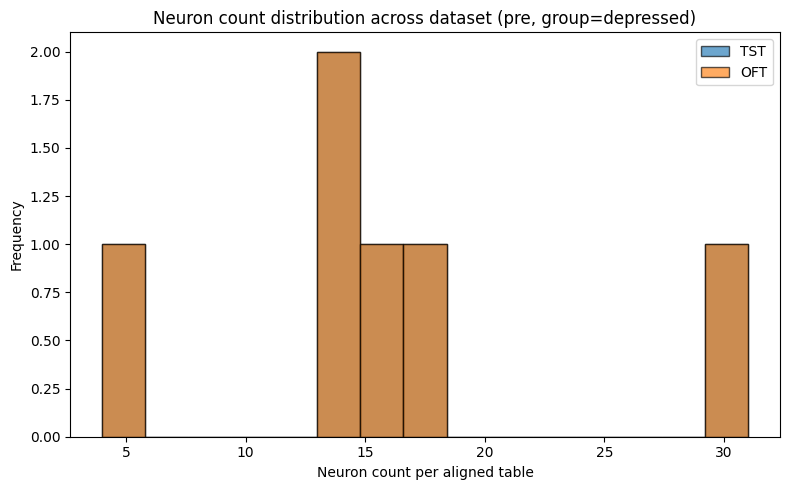

[Progress] Starting neuron resampling to a shared feature count...
[Progress] Saved resampled tables for CSDS0087
[Progress] Saved resampled tables for CSDS0126
[Fallback] CSDS5776 TST: 14 neurons available; sampling with replacement to reach 15.
[Fallback] CSDS5776 OFT: 14 neurons available; sampling with replacement to reach 15.
[Progress] Saved resampled tables for CSDS5776
[Fallback] CSDS5797 TST: 13 neurons available; sampling with replacement to reach 15.
[Fallback] CSDS5797 OFT: 13 neurons available; sampling with replacement to reach 15.
[Progress] Saved resampled tables for CSDS5797
[Progress] Saved resampled tables for LHQ30
[QC] Excluding LHQ50 from resampling: below threshold: TST=4, OFT=4, minimum required=10
[Progress] Saved resampling QC to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\neuron_resampling_qc.csv
[Progress] Saved resampled inventory to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\resampled_signal_inventory.csv
[Progress] Running logisti

,mouse_id,apply_minmax_scaler,tst_timepoints,oft_timepoints,shared_timepoints,feature_count,train_samples,test_samples,accuracy,qc_status,exclude_reason
0,CSDS0087,True,2993,2993,2993,15,2993,2993,0.977949,included,
1,CSDS0126,True,3000,3000,3000,15,3000,3000,0.886000,included,
2,CSDS5776,True,2999,2999,2999,15,2999,2999,0.959987,included,
3,CSDS5797,True,2995,2995,2995,15,2995,2995,0.933556,included,
4,LHQ30,True,2995,2995,2995,15,2995,2995,0.775960,included,


In [ ]:
print("[Progress] Resolving mouse list...")
if auto_discover_mice:
    mice_ids = discover_mice_ids(project_path, model, condition)
    print(f"[Progress] Auto-discovered {len(mice_ids)} mice under condition={condition!r}.")
else:
    print(f"[Progress] Using user-provided mouse list with n={len(mice_ids)}.")

if len(mice_ids) == 0:
    raise ValueError("No mice found. Please check project_path/model/condition or provide mice_ids explicitly.")

print("[Progress] Reading aligned tables and collecting QC records...")
inventory_records = []
for mouse_id in mice_ids:
    inventory_records.append(
        summarize_mouse_record(
            mouse_id=mouse_id,
            project_path=project_path,
            model=model,
            condition=condition,
            require_both_modalities=require_both_modalities,
        )
    )

inventory_df = pd.DataFrame(inventory_records)
valid_inventory_df = inventory_df[inventory_df["qc_status"] == "ok"].copy()
excluded_inventory_df = inventory_df[inventory_df["qc_status"] != "ok"].copy()

if valid_inventory_df.empty:
    raise ValueError("All records were excluded. Please inspect inventory_df and file paths.")

inventory_csv = os.path.join(save_root, "paired_signal_inventory.csv")
inventory_df.to_csv(inventory_csv, index=False)
print(f"[Progress] Saved inventory table to: {inventory_csv}")
print(f"[Progress] Valid mice: {len(valid_inventory_df)}")
print(f"[Progress] Excluded mice: {len(excluded_inventory_df)}")

neuron_count_long_df = build_neuron_count_long_table(valid_inventory_df)

plt.figure(figsize=figure_size)
plt.hist(
    neuron_count_long_df.loc[neuron_count_long_df["task"] == "TST", "neuron_count"],
    bins=hist_bins,
    alpha=alpha_tst,
    label="TST",
    edgecolor="black",
)
plt.hist(
    neuron_count_long_df.loc[neuron_count_long_df["task"] == "OFT", "neuron_count"],
    bins=hist_bins,
    alpha=alpha_oft,
    label="OFT",
    edgecolor="black",
)
plt.xlabel("Neuron count per aligned table")
plt.ylabel("Frequency")
plt.title(f"Neuron count distribution across dataset ({condition}, group={group})")
plt.legend()
plt.tight_layout()
hist_png = os.path.join(save_root, "neuron_count_histogram.png")
plt.savefig(hist_png, dpi=200, bbox_inches="tight")
print(f"[Progress] Saved histogram to: {hist_png}")
plt.show()

print("[Progress] Starting neuron resampling to a shared feature count...")
sampling_rng = np.random.default_rng(neuron_sampling_random_seed)
resampling_records = []
resampled_inventory_records = []

for _, row in valid_inventory_df.iterrows():
    mouse_id = row["mouse_id"]
    tst_path = Path(row["tst_path"])
    oft_path = Path(row["oft_path"])
    tst_df = read_aligned_table(tst_path)
    oft_df = read_aligned_table(oft_path)

    tst_neurons = tst_df.shape[1]
    oft_neurons = oft_df.shape[1]

    if tst_neurons < minimum_neuron_threshold or oft_neurons < minimum_neuron_threshold:
        exclude_reason = (
            f"below threshold: TST={tst_neurons}, OFT={oft_neurons}, "
            f"minimum required={minimum_neuron_threshold}"
        )
        print(f"[QC] Excluding {mouse_id} from resampling: {exclude_reason}")
        resampling_records.append({
            "mouse_id": mouse_id,
            "tst_neurons": tst_neurons,
            "oft_neurons": oft_neurons,
            "target_neuron_count": target_neuron_count,
            "minimum_neuron_threshold": minimum_neuron_threshold,
            "qc_status": "excluded",
            "exclude_reason": exclude_reason,
            "tst_sampling_mode": "not_sampled",
            "oft_sampling_mode": "not_sampled",
            "tst_selected_indices": "",
            "oft_selected_indices": "",
            "tst_output_path": "",
            "oft_output_path": "",
        })
        continue

    tst_sampled_df, tst_selected_idx, tst_sampling_mode, _ = sample_neuron_columns(
        df=tst_df,
        target_count=target_neuron_count,
        min_count=minimum_neuron_threshold,
        rng=sampling_rng,
        task_name="TST",
        mouse_id=mouse_id,
    )
    oft_sampled_df, oft_selected_idx, oft_sampling_mode, _ = sample_neuron_columns(
        df=oft_df,
        target_count=target_neuron_count,
        min_count=minimum_neuron_threshold,
        rng=sampling_rng,
        task_name="OFT",
        mouse_id=mouse_id,
    )

    mouse_save_dir = os.path.join(resampled_save_root, mouse_id)
    os.makedirs(mouse_save_dir, exist_ok=True)
    tst_output_path = os.path.join(mouse_save_dir, f"{mouse_id}_{condition}_aligned_table_TST_resampled15.csv")
    oft_output_path = os.path.join(mouse_save_dir, f"{mouse_id}_{condition}_aligned_table_OFT_resampled15.csv")

    tst_sampled_df.to_csv(tst_output_path, index=False)
    oft_sampled_df.to_csv(oft_output_path, index=False)

    resampling_records.append({
        "mouse_id": mouse_id,
        "tst_neurons": tst_neurons,
        "oft_neurons": oft_neurons,
        "target_neuron_count": target_neuron_count,
        "minimum_neuron_threshold": minimum_neuron_threshold,
        "qc_status": "included",
        "exclude_reason": "",
        "tst_sampling_mode": tst_sampling_mode,
        "oft_sampling_mode": oft_sampling_mode,
        "tst_selected_indices": ",".join(map(str, tst_selected_idx)),
        "oft_selected_indices": ",".join(map(str, oft_selected_idx)),
        "tst_output_path": tst_output_path,
        "oft_output_path": oft_output_path,
    })
    resampled_inventory_records.append({
        "mouse_id": mouse_id,
        "tst_path": str(tst_path),
        "oft_path": str(oft_path),
        "tst_output_path": tst_output_path,
        "oft_output_path": oft_output_path,
        "tst_sampling_mode": tst_sampling_mode,
        "oft_sampling_mode": oft_sampling_mode,
    })
    print(f"[Progress] Saved resampled tables for {mouse_id}")

resampling_qc_df = pd.DataFrame(resampling_records)
resampled_inventory_df = pd.DataFrame(resampled_inventory_records)

resampling_qc_csv = os.path.join(save_root, "neuron_resampling_qc.csv")
resampled_inventory_csv = os.path.join(save_root, "resampled_signal_inventory.csv")
resampling_qc_df.to_csv(resampling_qc_csv, index=False)
resampled_inventory_df.to_csv(resampled_inventory_csv, index=False)
print(f"[Progress] Saved resampling QC to: {resampling_qc_csv}")
print(f"[Progress] Saved resampled inventory to: {resampled_inventory_csv}")

if resampled_inventory_df.empty:
    raise ValueError("No resampled mice were available for logistic regression.")

print("[Progress] Running logistic regression and follow-up analyses...")
randomization_rng = np.random.default_rng(randomization_random_seed)
observed_records = []
label_shuffle_records = []
resample_seed_records = []
synthetic_neuron_records = []
label_shuffle_null_rows = []
resample_seed_rows = []
synthetic_neuron_rows = []

for _, row in resampled_inventory_df.iterrows():
    mouse_id = row["mouse_id"]
    print(f"[Progress] Processing {mouse_id}...")

    observed_result, X_observed, y_observed, shared_timepoints, _, _ = run_logreg_from_dfs(
        tst_df=pd.read_csv(row["tst_output_path"]),
        oft_df=pd.read_csv(row["oft_output_path"]),
        apply_scaler=apply_minmax_scaler,
        test_size=logreg_test_size,
        random_state=logreg_random_state,
        max_iter=logreg_max_iter,
    )

    observed_records.append({
        "mouse_id": mouse_id,
        "apply_minmax_scaler": apply_minmax_scaler,
        "tst_timepoints": shared_timepoints,
        "oft_timepoints": shared_timepoints,
        "shared_timepoints": shared_timepoints,
        "feature_count": observed_result["feature_count"],
        "train_samples": observed_result["train_samples"],
        "test_samples": observed_result["test_samples"],
        "accuracy": observed_result["accuracy"],
        "qc_status": "included",
        "exclude_reason": "",
    })
    print(f"[Progress] {mouse_id}: observed accuracy = {observed_result['accuracy']:.2%}")

    label_shuffle_null = []
    for iter_idx in range(label_shuffle_iterations):
        shuffled_y = randomization_rng.permutation(y_observed)
        null_result = compute_logreg_accuracy(
            X=X_observed,
            y=shuffled_y,
            test_size=logreg_test_size,
            random_state=logreg_random_state + iter_idx + 1,
            max_iter=logreg_max_iter,
        )
        label_shuffle_null.append(null_result["accuracy"])
        label_shuffle_null_rows.append({
            "mouse_id": mouse_id,
            "iteration": iter_idx,
            "null_accuracy": null_result["accuracy"],
        })

    label_record = {
        "mouse_id": mouse_id,
        "iterations": label_shuffle_iterations,
        "shared_timepoints": shared_timepoints,
        "feature_count": observed_result["feature_count"],
        "qc_status": "included",
        "exclude_reason": "",
    }
    label_record.update(summarize_null_distribution(observed_result["accuracy"], label_shuffle_null))
    label_shuffle_records.append(label_record)
    print(f"[Progress] {mouse_id}: label-shuffle empirical p = {label_record['empirical_p_value']:.4f}")

    original_tst_df = read_aligned_table(Path(row["tst_path"]))
    original_oft_df = read_aligned_table(Path(row["oft_path"]))

    resample_seed_accuracies = []
    for iter_idx in range(resample_seed_iterations):
        iter_rng = np.random.default_rng(randomization_random_seed + iter_idx + 10000)
        tst_resampled_df, _, _, _ = sample_neuron_columns(
            df=original_tst_df,
            target_count=target_neuron_count,
            min_count=minimum_neuron_threshold,
            rng=iter_rng,
            task_name="TST",
            mouse_id=mouse_id,
        )
        oft_resampled_df, _, _, _ = sample_neuron_columns(
            df=original_oft_df,
            target_count=target_neuron_count,
            min_count=minimum_neuron_threshold,
            rng=iter_rng,
            task_name="OFT",
            mouse_id=mouse_id,
        )
        iter_result, _, _, _, _, _ = run_logreg_from_dfs(
            tst_df=tst_resampled_df,
            oft_df=oft_resampled_df,
            apply_scaler=apply_minmax_scaler,
            test_size=logreg_test_size,
            random_state=logreg_random_state,
            max_iter=logreg_max_iter,
        )
        resample_seed_accuracies.append(iter_result["accuracy"])
        resample_seed_rows.append({
            "mouse_id": mouse_id,
            "iteration": iter_idx,
            "resampled_accuracy": iter_result["accuracy"],
        })

    resample_seed_records.append({
        "mouse_id": mouse_id,
        "iterations": resample_seed_iterations,
        "observed_accuracy": observed_result["accuracy"],
        "resample_mean_accuracy": float(np.mean(resample_seed_accuracies)),
        "resample_median_accuracy": float(np.median(resample_seed_accuracies)),
        "resample_std_accuracy": float(np.std(resample_seed_accuracies, ddof=1)) if len(resample_seed_accuracies) > 1 else 0.0,
        "resample_min_accuracy": float(np.min(resample_seed_accuracies)),
        "resample_max_accuracy": float(np.max(resample_seed_accuracies)),
        "shared_timepoints": shared_timepoints,
        "feature_count": observed_result["feature_count"],
    })
    print(f"[Progress] {mouse_id}: resample-seed mean accuracy = {np.mean(resample_seed_accuracies):.2%}")

    synthetic_accuracies = []
    for iter_idx in range(synthetic_neuron_iterations):
        iter_rng = np.random.default_rng(randomization_random_seed + iter_idx + 20000)
        base_tst_df, _, _, _ = sample_neuron_columns(
            df=original_tst_df,
            target_count=target_neuron_count,
            min_count=minimum_neuron_threshold,
            rng=iter_rng,
            task_name="TST",
            mouse_id=mouse_id,
        )
        base_oft_df, _, _, _ = sample_neuron_columns(
            df=original_oft_df,
            target_count=target_neuron_count,
            min_count=minimum_neuron_threshold,
            rng=iter_rng,
            task_name="OFT",
            mouse_id=mouse_id,
        )
        synthetic_tst_df = generate_synthetic_df_from_mean_std(base_tst_df, iter_rng)
        synthetic_oft_df = generate_synthetic_df_from_mean_std(base_oft_df, iter_rng)
        iter_result, _, _, _, _, _ = run_logreg_from_dfs(
            tst_df=synthetic_tst_df,
            oft_df=synthetic_oft_df,
            apply_scaler=apply_minmax_scaler,
            test_size=logreg_test_size,
            random_state=logreg_random_state,
            max_iter=logreg_max_iter,
        )
        synthetic_accuracies.append(iter_result["accuracy"])
        synthetic_neuron_rows.append({
            "mouse_id": mouse_id,
            "iteration": iter_idx,
            "synthetic_accuracy": iter_result["accuracy"],
        })

    synthetic_ci_lower = float(np.percentile(synthetic_accuracies, 2.5))
    synthetic_ci_upper = float(np.percentile(synthetic_accuracies, 97.5))

    synthetic_neuron_records.append({
        "mouse_id": mouse_id,
        "iterations": synthetic_neuron_iterations,
        "observed_accuracy": observed_result["accuracy"],
        "synthetic_mean_accuracy": float(np.mean(synthetic_accuracies)),
        "synthetic_median_accuracy": float(np.median(synthetic_accuracies)),
        "synthetic_std_accuracy": float(np.std(synthetic_accuracies, ddof=1)) if len(synthetic_accuracies) > 1 else 0.0,
        "synthetic_min_accuracy": float(np.min(synthetic_accuracies)),
        "synthetic_max_accuracy": float(np.max(synthetic_accuracies)),
        "synthetic_ci_lower_95": synthetic_ci_lower,
        "synthetic_ci_upper_95": synthetic_ci_upper,
        "empirical_p_value": empirical_p_value(observed_result["accuracy"], synthetic_accuracies),
        "shared_timepoints": shared_timepoints,
        "feature_count": observed_result["feature_count"],
    })
    print(f"[Progress] {mouse_id}: synthetic-neuron mean accuracy = {np.mean(synthetic_accuracies):.2%}")

observed_accuracy_df = pd.DataFrame(observed_records)
label_shuffle_df = pd.DataFrame(label_shuffle_records)
resample_seed_df = pd.DataFrame(resample_seed_records)
synthetic_neuron_df = pd.DataFrame(synthetic_neuron_records)
label_shuffle_null_df = pd.DataFrame(label_shuffle_null_rows)
resample_seed_long_df = pd.DataFrame(resample_seed_rows)
synthetic_neuron_long_df = pd.DataFrame(synthetic_neuron_rows)

observed_summary_df = pd.DataFrame([{
    "n_mice": len(observed_accuracy_df),
    "mean_accuracy": observed_accuracy_df["accuracy"].mean() if not observed_accuracy_df.empty else np.nan,
    "median_accuracy": observed_accuracy_df["accuracy"].median() if not observed_accuracy_df.empty else np.nan,
    "min_accuracy": observed_accuracy_df["accuracy"].min() if not observed_accuracy_df.empty else np.nan,
    "max_accuracy": observed_accuracy_df["accuracy"].max() if not observed_accuracy_df.empty else np.nan,
    "std_accuracy": observed_accuracy_df["accuracy"].std() if not observed_accuracy_df.empty else np.nan,
}])
label_shuffle_summary_df = pd.DataFrame([{
    "n_mice": len(label_shuffle_df),
    "mean_observed_accuracy": label_shuffle_df["observed_accuracy"].mean() if not label_shuffle_df.empty else np.nan,
    "mean_null_accuracy": label_shuffle_df["null_mean_accuracy"].mean() if not label_shuffle_df.empty else np.nan,
    "median_empirical_p_value": label_shuffle_df["empirical_p_value"].median() if not label_shuffle_df.empty else np.nan,
}])
resample_seed_summary_df = pd.DataFrame([{
    "n_mice": len(resample_seed_df),
    "mean_observed_accuracy": resample_seed_df["observed_accuracy"].mean() if not resample_seed_df.empty else np.nan,
    "mean_resample_accuracy": resample_seed_df["resample_mean_accuracy"].mean() if not resample_seed_df.empty else np.nan,
    "mean_resample_std": resample_seed_df["resample_std_accuracy"].mean() if not resample_seed_df.empty else np.nan,
}])
synthetic_neuron_summary_df = pd.DataFrame([{
    "n_mice": len(synthetic_neuron_df),
    "mean_observed_accuracy": synthetic_neuron_df["observed_accuracy"].mean() if not synthetic_neuron_df.empty else np.nan,
    "mean_synthetic_accuracy": synthetic_neuron_df["synthetic_mean_accuracy"].mean() if not synthetic_neuron_df.empty else np.nan,
    "mean_synthetic_ci_lower_95": synthetic_neuron_df["synthetic_ci_lower_95"].mean() if not synthetic_neuron_df.empty else np.nan,
    "mean_synthetic_ci_upper_95": synthetic_neuron_df["synthetic_ci_upper_95"].mean() if not synthetic_neuron_df.empty else np.nan,
    "median_empirical_p_value": synthetic_neuron_df["empirical_p_value"].median() if not synthetic_neuron_df.empty else np.nan,
}])

observed_accuracy_csv = os.path.join(save_root, "logreg_resampled15_accuracy.csv")
observed_summary_csv = os.path.join(save_root, "logreg_resampled15_accuracy_summary.csv")
label_shuffle_csv = os.path.join(save_root, "logreg_label_shuffle_test.csv")
label_shuffle_summary_csv = os.path.join(save_root, "logreg_label_shuffle_summary.csv")
label_shuffle_null_csv = os.path.join(save_root, "logreg_label_shuffle_null_distribution.csv")
resample_seed_csv = os.path.join(save_root, "logreg_resample_seed_stability.csv")
resample_seed_summary_csv = os.path.join(save_root, "logreg_resample_seed_stability_summary.csv")
resample_seed_long_csv = os.path.join(save_root, "logreg_resample_seed_stability_long.csv")
synthetic_neuron_csv = os.path.join(save_root, "logreg_synthetic_neuron_test.csv")
synthetic_neuron_summary_csv = os.path.join(save_root, "logreg_synthetic_neuron_summary.csv")
synthetic_neuron_long_csv = os.path.join(save_root, "logreg_synthetic_neuron_long.csv")


print(f"[Progress] Saved observed accuracy table to: {observed_accuracy_csv}")
print(f"[Progress] Saved observed summary to: {observed_summary_csv}")
print(f"[Progress] Saved label-shuffle table to: {label_shuffle_csv}")
print(f"[Progress] Saved label-shuffle summary to: {label_shuffle_summary_csv}")
print(f"[Progress] Saved label-shuffle null distribution to: {label_shuffle_null_csv}")
print(f"[Progress] Saved resample-seed table to: {resample_seed_csv}")
print(f"[Progress] Saved resample-seed summary to: {resample_seed_summary_csv}")
print(f"[Progress] Saved synthetic-neuron table to: {synthetic_neuron_csv}")
print(f"[Progress] Saved synthetic-neuron summary to: {synthetic_neuron_summary_csv}")

observed_accuracy_df


## Preview

The preview below supports quick manual QC.

- The bar plot compares observed accuracy with the label-shuffle null mean and the synthetic-neuron mean.
- The line plot shows one real neuron signal trace from the first included mouse after resampling.


In [ ]:
synthetic_neuron_df

[Preview] Observed accuracy summary


,n_mice,mean_accuracy,median_accuracy,min_accuracy,max_accuracy,std_accuracy
0,5,0.90669,0.933556,0.77596,0.977949,0.080868


[Preview] Label-shuffle summary


,n_mice,mean_observed_accuracy,mean_null_accuracy,median_empirical_p_value
0,5,0.90669,0.500261,0.004975


[Preview] Resample-seed stability summary


,n_mice,mean_observed_accuracy,mean_resample_accuracy,mean_resample_std
0,5,0.90669,0.937204,0.027835


[Preview] Synthetic-neuron summary


,n_mice,mean_observed_accuracy,mean_synthetic_accuracy,mean_synthetic_ci_lower_95,mean_synthetic_ci_upper_95,median_empirical_p_value
0,5,0.90669,0.719796,0.640999,0.802143,0.004975


[Preview] Saved accuracy comparison plot to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\randomization_accuracy_comparison.png


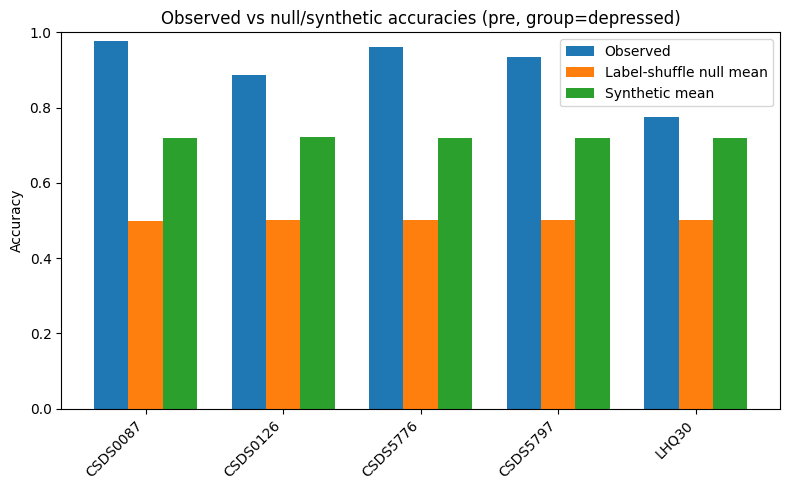

[Preview] Saved trace preview to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\trace_preview_CSDS0087_neuron0.png


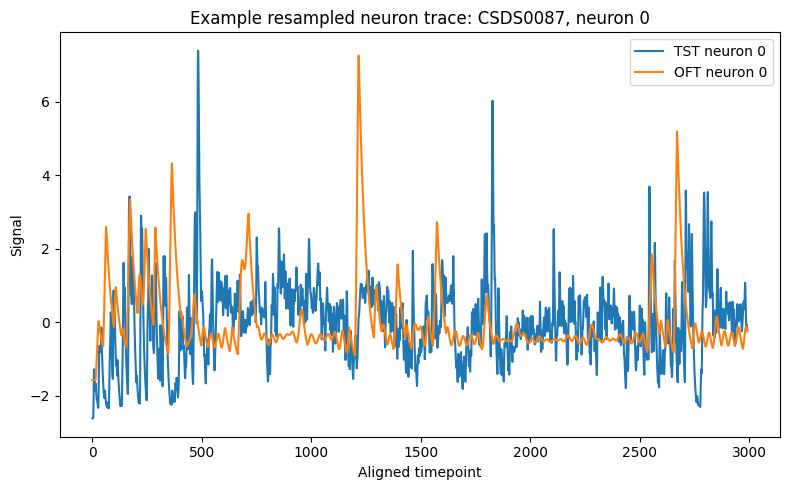

[Preview] Per-mouse observed results


,mouse_id,apply_minmax_scaler,tst_timepoints,oft_timepoints,shared_timepoints,feature_count,train_samples,test_samples,accuracy,qc_status,exclude_reason
0,CSDS0087,True,2993,2993,2993,15,2993,2993,0.977949,included,
1,CSDS0126,True,3000,3000,3000,15,3000,3000,0.886000,included,
2,CSDS5776,True,2999,2999,2999,15,2999,2999,0.959987,included,
3,CSDS5797,True,2995,2995,2995,15,2995,2995,0.933556,included,
4,LHQ30,True,2995,2995,2995,15,2995,2995,0.775960,included,


[Preview] Per-mouse label-shuffle results


,mouse_id,iterations,shared_timepoints,feature_count,qc_status,exclude_reason,observed_accuracy,null_mean_accuracy,null_median_accuracy,null_std_accuracy,null_min_accuracy,null_max_accuracy,empirical_p_value
0,CSDS0087,200,2993,15,included,,0.977949,0.499795,0.500501,0.009050,0.475777,0.524223,0.004975
1,CSDS0126,200,3000,15,included,,0.886000,0.500295,0.499667,0.009264,0.478667,0.524000,0.004975
2,CSDS5776,200,2999,15,included,,0.959987,0.500382,0.500667,0.009079,0.477159,0.524842,0.004975
3,CSDS5797,200,2995,15,included,,0.933556,0.500037,0.498831,0.008692,0.480134,0.528548,0.004975
4,LHQ30,200,2995,15,included,,0.775960,0.500798,0.500835,0.008211,0.475125,0.524875,0.004975


[Preview] Per-mouse resample-seed stability


,mouse_id,iterations,observed_accuracy,resample_mean_accuracy,resample_median_accuracy,resample_std_accuracy,resample_min_accuracy,resample_max_accuracy,shared_timepoints,feature_count
0,CSDS0087,200,0.977949,0.982461,0.982626,0.004592,0.967257,0.993652,2993,15
1,CSDS0126,200,0.886000,0.944513,0.969667,0.051025,0.772667,0.993667,3000,15
2,CSDS5776,200,0.959987,0.946761,0.948983,0.018348,0.884962,0.986996,2999,15
3,CSDS5797,200,0.933556,0.945332,0.949583,0.020696,0.870785,0.976628,2995,15
4,LHQ30,200,0.775960,0.866953,0.874457,0.044513,0.723539,0.946244,2995,15


[Preview] Per-mouse synthetic-neuron results


,mouse_id,iterations,observed_accuracy,synthetic_mean_accuracy,synthetic_median_accuracy,synthetic_std_accuracy,synthetic_min_accuracy,synthetic_max_accuracy,synthetic_ci_lower_95,synthetic_ci_upper_95,empirical_p_value,shared_timepoints,feature_count
0,CSDS0087,200,0.977949,0.719651,0.720180,0.042810,0.588707,0.831941,0.645489,0.802097,0.004975,2993,15
1,CSDS0126,200,0.886000,0.720847,0.722000,0.042522,0.583667,0.837333,0.636533,0.808508,0.004975,3000,15
2,CSDS5776,200,0.959987,0.720070,0.721074,0.041297,0.590197,0.829276,0.645015,0.805310,0.004975,2999,15
3,CSDS5797,200,0.933556,0.719529,0.718030,0.041365,0.610684,0.830718,0.636027,0.801486,0.004975,2995,15
4,LHQ30,200,0.775960,0.718883,0.717195,0.041573,0.606678,0.843072,0.641928,0.793314,0.074627,2995,15


In [ ]:
print("[Preview] Observed accuracy summary")
display(observed_summary_df)
print("[Preview] Label-shuffle summary")
display(label_shuffle_summary_df)
print("[Preview] Resample-seed stability summary")
display(resample_seed_summary_df)
print("[Preview] Synthetic-neuron summary")
display(synthetic_neuron_summary_df)

if save_preview_plots and not observed_accuracy_df.empty and not label_shuffle_df.empty and not synthetic_neuron_df.empty:
    comparison_df = observed_accuracy_df[["mouse_id", "accuracy"]].merge(
        label_shuffle_df[["mouse_id", "null_mean_accuracy"]].rename(columns={"null_mean_accuracy": "label_shuffle_null_mean"}),
        on="mouse_id",
        how="inner",
    ).merge(
        synthetic_neuron_df[["mouse_id", "synthetic_mean_accuracy"]],
        on="mouse_id",
        how="inner",
    )

    if comparison_df.empty:
        print("[Fallback] No overlapping mice for accuracy-comparison plot.")
    else:
        x = np.arange(len(comparison_df))
        width = 0.25
        plt.figure(figsize=(max(8, len(comparison_df) * 1.1), figure_size[1]))
        plt.bar(x - width, comparison_df["accuracy"], width=width, label="Observed")
        plt.bar(x, comparison_df["label_shuffle_null_mean"], width=width, label="Label-shuffle null mean")
        plt.bar(x + width, comparison_df["synthetic_mean_accuracy"], width=width, label="Synthetic mean")
        plt.xticks(x, comparison_df["mouse_id"], rotation=45, ha="right")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.title(f"Observed vs null/synthetic accuracies ({condition}, group={group})")
        plt.legend()
        plt.tight_layout()
        comparison_png = os.path.join(save_root, "randomization_accuracy_comparison.png")
        plt.savefig(comparison_png, dpi=200, bbox_inches="tight")
        print(f"[Preview] Saved accuracy comparison plot to: {comparison_png}")
        plt.show()
else:
    print("[Fallback] Not enough data for the accuracy-comparison plot.")

if not resampled_inventory_df.empty:
    preview_mouse_id = resampled_inventory_df.iloc[0]["mouse_id"]
    preview_row = resampled_inventory_df.iloc[0]
    preview_tst_df = pd.read_csv(preview_row["tst_output_path"])
    preview_oft_df = pd.read_csv(preview_row["oft_output_path"])
    shared_timepoints = min(preview_tst_df.shape[0], preview_oft_df.shape[0])
    preview_tst_df = preview_tst_df.iloc[:shared_timepoints, :]
    preview_oft_df = preview_oft_df.iloc[:shared_timepoints, :]
    preview_neuron_idx = 0
    time_axis = np.arange(shared_timepoints)
    plt.figure(figsize=figure_size)
    plt.plot(time_axis, preview_tst_df.iloc[:, preview_neuron_idx], label="TST neuron 0")
    plt.plot(time_axis, preview_oft_df.iloc[:, preview_neuron_idx], label="OFT neuron 0")
    plt.xlabel("Aligned timepoint")
    plt.ylabel("Signal")
    plt.title(f"Example resampled neuron trace: {preview_mouse_id}, neuron 0")
    plt.legend()
    plt.tight_layout()
    trace_png = os.path.join(save_root, f"trace_preview_{preview_mouse_id}_neuron0.png")
    plt.savefig(trace_png, dpi=200, bbox_inches="tight")
    print(f"[Preview] Saved trace preview to: {trace_png}")
    plt.show()
else:
    print("[Fallback] No resampled inventory available for trace preview.")

print("[Preview] Per-mouse observed results")
display(observed_accuracy_df)
print("[Preview] Per-mouse label-shuffle results")
display(label_shuffle_df)
print("[Preview] Per-mouse resample-seed stability")
display(resample_seed_df)
print("[Preview] Per-mouse synthetic-neuron results")
display(synthetic_neuron_df)


[Stats] Repeated-measures one-way ANOVA
                Anova
          F Value Num DF Den DF Pr > F
--------------------------------------
condition 94.8814 2.0000 8.0000 0.0000


[Stats] Pairwise paired t-tests with Holm correction


,comparison,n_mice,t_stat,raw_p_value,holm_corrected_p,significant,stars
0,Observed vs Label-Shuffle,5,11.193682,3.626590e-04,7.253179e-04,True,***
1,Observed vs Synthetic,5,5.186383,6.577376e-03,6.577376e-03,True,**
2,Label-Shuffle vs Synthetic,5,-543.409574,6.880695e-11,2.064208e-10,True,***


[Preview] Saved ANOVA plot to: G:\XJN_M2project\signal_data\test2\pre\group\depressed\observed_labelshuffle_synthetic_anova.png


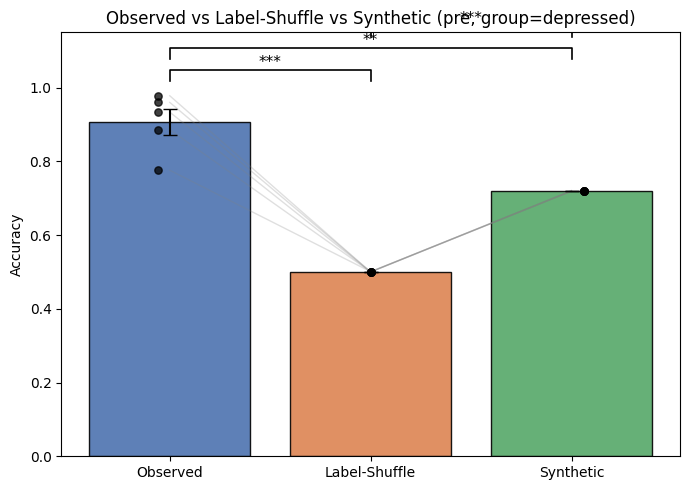

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import sem, ttest_rel
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_sig_bar(ax, x1, x2, y, h, text, lw=1.2):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=lw)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=11)


plot_df = observed_accuracy_df[["mouse_id", "accuracy"]].rename(
    columns={"accuracy": "Observed"}
).merge(
    label_shuffle_df[["mouse_id", "null_mean_accuracy"]].rename(
        columns={"null_mean_accuracy": "Label-Shuffle"}
    ),
    on="mouse_id",
    how="inner",
).merge(
    synthetic_neuron_df[["mouse_id", "synthetic_mean_accuracy"]].rename(
        columns={"synthetic_mean_accuracy": "Synthetic"}
    ),
    on="mouse_id",
    how="inner",
)

if plot_df.empty:
    print("[Fallback] No overlapping mice available for ANOVA plot.")
else:
    long_df = plot_df.melt(
        id_vars="mouse_id",
        value_vars=["Observed", "Label-Shuffle", "Synthetic"],
        var_name="condition",
        value_name="accuracy",
    )

    # repeated-measures one-way ANOVA
    anova_res = AnovaRM(
        data=long_df,
        depvar="accuracy",
        subject="mouse_id",
        within=["condition"],
    ).fit()

    print("[Stats] Repeated-measures one-way ANOVA")
    print(anova_res)

    # pairwise paired t-tests + Holm correction
    pairs = [
        ("Observed", "Label-Shuffle"),
        ("Observed", "Synthetic"),
        ("Label-Shuffle", "Synthetic"),
    ]

    raw_pvals = []
    pairwise_rows = []

    for a, b in pairs:
        merged = plot_df[["mouse_id", a, b]].dropna()
        stat, pval = ttest_rel(merged[a], merged[b])
        raw_pvals.append(pval)
        pairwise_rows.append(
            {
                "comparison": f"{a} vs {b}",
                "n_mice": len(merged),
                "t_stat": stat,
                "raw_p_value": pval,
            }
        )

    reject, pvals_corrected, _, _ = multipletests(raw_pvals, method="holm")

    for row, p_corr, rej in zip(pairwise_rows, pvals_corrected, reject):
        row["holm_corrected_p"] = p_corr
        row["significant"] = bool(rej)
        row["stars"] = p_to_stars(p_corr)

    pairwise_df = pd.DataFrame(pairwise_rows)
    print("\n[Stats] Pairwise paired t-tests with Holm correction")
    display(pairwise_df)

    # plot
    condition_order = ["Observed", "Label-Shuffle", "Synthetic"]
    means = [plot_df[c].mean() for c in condition_order]
    errors = [sem(plot_df[c], nan_policy="omit") for c in condition_order]

    x = np.arange(len(condition_order))
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    plt.figure(figsize=(7, 5))
    ax = plt.gca()

    ax.bar(x, means, yerr=errors, capsize=5, color=colors, edgecolor="black", alpha=0.9)

    # overlay per-mouse points
    jitter_offsets = [-0.06, 0.00, 0.06]
    for i, cond in enumerate(condition_order):
        ax.scatter(
            np.full(len(plot_df), x[i] + jitter_offsets[i]),
            plot_df[cond],
            color="black",
            s=28,
            alpha=0.75,
            zorder=3,
        )

    # connect same mouse across conditions
    for _, row in plot_df.iterrows():
        ax.plot(
            x,
            [row["Observed"], row["Label-Shuffle"], row["Synthetic"]],
            color="gray",
            alpha=0.25,
            lw=1,
            zorder=1,
        )

    ax.set_xticks(x, condition_order)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.15)
    ax.set_title(f"Observed vs Label-Shuffle vs Synthetic ({condition}, group={group})")

    # significance bars
    max_y = max(max(means), plot_df[condition_order].to_numpy().max())
    h = 0.03
    gap = 0.06

    pair_to_x = {
        "Observed vs Label-Shuffle": (0, 1),
        "Observed vs Synthetic": (0, 2),
        "Label-Shuffle vs Synthetic": (1, 2),
    }

    y0 = max_y + 0.04
    for idx, row in pairwise_df.iterrows():
        x1, x2 = pair_to_x[row["comparison"]]
        add_sig_bar(ax, x1, x2, y0 + idx * gap, h, row["stars"])

    plt.tight_layout()

    anova_plot_png = os.path.join(save_root, "observed_labelshuffle_synthetic_anova.png")
    plt.savefig(anova_plot_png, dpi=200, bbox_inches="tight")
    print(f"[Preview] Saved ANOVA plot to: {anova_plot_png}")
    plt.show()

In [ ]:
comparision_csv = os.path.join(save_root, "logreg_comparision_accuracy.csv")
comparison_df.to_csv(comparision_csv, index=False)